In [49]:
import sys, os, importlib.util
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import lambda2nu, nu2lambda, c

from IPython.core.display import HTML
from IPython.core.pylabtools import figsize
from IPython.display import display, Math

HTML(""""
<style>
.output_png{
     display: table-cell;
     text-align: center;
     vertical-align: middle;
     }
</style>
""")

# Função para substituir importlib.load_source(nome, caminho)
def carregar_fonte(nome_modulo, caminho_arquivo):
    spec = importlib.util.spec_from_file_location(nome_modulo, caminho_arquivo)
    modulo = importlib.util.module_from_spec(spec)
    sys.modules[nome_modulo] = modulo
    spec.loader.exec_module(modulo)
    
    return modulo

#lumapiFile = "/opt/lumerical/v221/api/python/lumapi.py"
lumapiFile = "C:\\Program Files\\Lumerical\\v221\\api\\python\\lumapi.py"
lumapi = carregar_fonte("lumapi", lumapiFile)
modeApi = lumapi.MODE(hide = False)

C:\Program Files\Lumerical\v221\api\python\lumapi.py:796: SyntaxWarning: invalid escape sequence '\s'
  message = re.sub('^(Error:)\s(prompt line)\s[0-9]+:', '', str(rvals[2])).strip()


Geometria

In [50]:
microns = 1e-6
wco = 1.5 *microns
H = 0.4 *microns
f = 0.5
h_et = f * H
waveguide_width = 7 *microns
waveguide_len = 10 * microns

In [51]:
modeApi.addrect()
modeApi.set("name", "lower_rect")
modeApi.set("x", 0)
modeApi.set("y", 0)
modeApi.set("z", 0)
modeApi.set("x span", waveguide_width)
modeApi.set("y span", H - h_et)
modeApi.set("z span", waveguide_len)
modeApi.set("material", "Si (Silicon) - Palik")

modeApi.addrect()
modeApi.set("name", "upper_rect")
modeApi.set("x", 0)
modeApi.set("y", modeApi.getnamed("lower_rect", "y span")/2 + (h_et/2))
modeApi.set("z", 0)
modeApi.set("x span", wco)
modeApi.set("y span", h_et)
modeApi.set("z span", waveguide_len)
modeApi.set("material", "Si (Silicon) - Palik")

modeApi.addfde()
modeApi.set("solver type", 3)
modeApi.set("x", 0)
modeApi.set("y", ((modeApi.getnamed("lower_rect", "y span")+modeApi.getnamed("upper_rect", "y span"))/2) - (modeApi.getnamed("lower_rect", "y span")/2))
modeApi.set("z", 0)
modeApi.set("x span", 9*microns)
modeApi.set("y span", 3*microns)
modeApi.set("background material", "SiO2 (Glass) - Palik")

modeApi.addmesh()
modeApi.set("x", 0)
modeApi.set("y", ((modeApi.getnamed("lower_rect", "y span")+modeApi.getnamed("upper_rect", "y span"))/2) - (modeApi.getnamed("lower_rect", "y span")/2))
modeApi.set("z", 0)
modeApi.set("x span", waveguide_width)
modeApi.set("y span", H)
modeApi.set("z span", waveguide_len)

Plotagem neff versus wco

In [53]:
import numpy as np
import matplotlib.pyplot as plt

In [54]:
vec_wco = np.linspace(0.5 *microns, 3 *microns, 80)
matriz_modos = np.zeros((7, len(vec_wco), 2))

In [55]:
for i in range(len(vec_wco)):
    modeApi.switchtolayout()
    modeApi.setnamed("upper_rect", "x span", vec_wco[i])
    modeApi.redraw()
    modeApi.findmodes()

    for j in range(0, 7):
        matriz_modos[j, i, 0] = modeApi.real(modeApi.getdata("mode" + modeApi.num2str(j+1), "neff"))
        matriz_modos[j, i, 1] = modeApi.getdata("mode" + modeApi.num2str(j+1), "TE polarization fraction")

<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\m'
C:\Users\mariana.lima\AppData\Local\Temp\ipykernel_17744\67778457.py:29: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('Comprimento do guia ($\mu m$)')


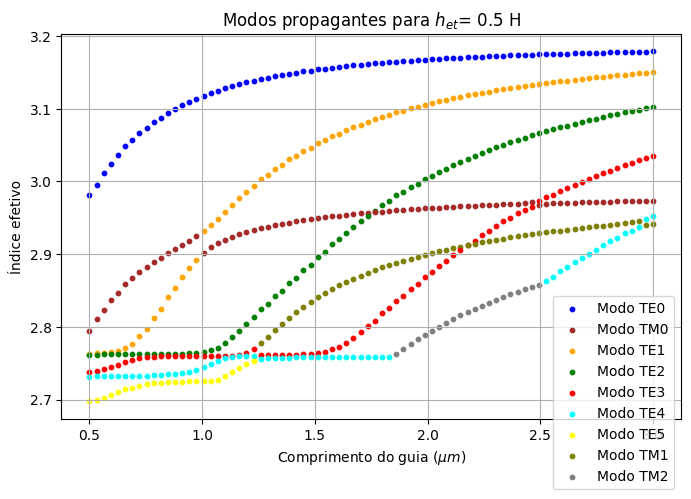

In [57]:
plt.figure(figsize=(8, 5))

lista_cores_TE = ["blue", "orange", "green", "red", "cyan", "yellow", "purple"]
lista_cores_TM = ["brown", "olive", "gray", "lightgreen", "pink", "sandybrown"]

contagemTE = -1
contagemTM = -1

for i in range(len(vec_wco)):
    modoTE = -1
    modoTM = -1
    for j in range(0,7):

        if (matriz_modos[j, i, 1] >= 0.5):
            modoTE = modoTE + 1
            if (contagemTE < modoTE):
                plt.scatter(vec_wco[i]/microns, matriz_modos[j, i, 0], color=lista_cores_TE[modoTE], s=10, label='Modo TE%g' % modoTE)
                contagemTE = contagemTE + 1
            else:
                plt.scatter(vec_wco[i]/microns, matriz_modos[j, i, 0], color=lista_cores_TE[modoTE], s=10)
        else:
            modoTM = modoTM + 1
            if (contagemTM < modoTM):
                plt.scatter(vec_wco[i]/microns, matriz_modos[j, i, 0], color=lista_cores_TM[modoTM], s=10, label='Modo TM%g' % modoTM)
                contagemTM = contagemTM + 1
            else:
                plt.scatter(vec_wco[i]/microns, matriz_modos[j, i, 0], color=lista_cores_TM[modoTM], s=10)

plt.xlabel('Comprimento do guia ($\mu m$)')
plt.ylabel('Índice efetivo')
plt.title('Modos propagantes para $h_{et}$= 0.5 H')
plt.legend(bbox_to_anchor=(1, -0.2), loc='lower right')
plt.grid(True)

plt.show()

In [61]:
print(matriz_modos[2, 16, 1])

0.4473659372422688
